# Domain Analysis — Complete EDA
Extends the initial exploration with three critical missing analyses:
1. Cross-split mean spectrum comparison (same class, all splits)
2. Within-class variance per split (quantifies domain shift magnitude)
3. PCA restricted to shared classes only (reveals cluster alignment)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

DATA_PATH = "../data/raw"
SPLITS = ["reference", "finetune", "test", "2018clinical", "2019clinical"]
SHARED_CLASSES = [0, 2, 3, 5, 6]       # Classes present in ALL splits
CLINICAL_SPLITS = ["2018clinical", "2019clinical"]
SOURCE_SPLITS   = ["reference", "finetune", "test"]

SPLIT_COLORS = {
    "reference":    "#1D9E75",
    "finetune":     "#534AB7",
    "test":         "#888780",
    "2018clinical": "#D85A30",
    "2019clinical": "#BA7517",
}

In [2]:
# ================================================================
# LOAD ALL SPLITS
# ================================================================
data = {}
for split in SPLITS:
    X = np.load(os.path.join(DATA_PATH, f"X_{split}.npy"))
    y = np.load(os.path.join(DATA_PATH, f"y_{split}.npy"))
    data[split] = {"X": X, "y": y.astype(int)}
    print(f"{split:>14s}  shape={X.shape}  classes={sorted(np.unique(y).tolist())}")

     reference  shape=(60000, 1000)  classes=[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0]
      finetune  shape=(3000, 1000)  classes=[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0]
          test  shape=(3000, 1000)  classes=[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0]
  2018clinical  shape=(10000, 1000)  classes=[0.0, 2.0, 3.0, 5.0, 6.0]
  2019clinical  shape=(2500, 1000)  classes=[0.0, 2.0, 3.0, 5.0, 6.0]


---
## Gap 1 — Cross-split mean spectrum (same class, all splits)

**What this tells us:** If the mean spectrum for class X looks identical across
reference and clinical splits, domain shift is minimal and a model trained on
reference should transfer well. If the curves diverge (baseline offset, peak
shift, amplitude change), we know exactly what the domain gap looks like and
can design preprocessing/augmentation to close it.

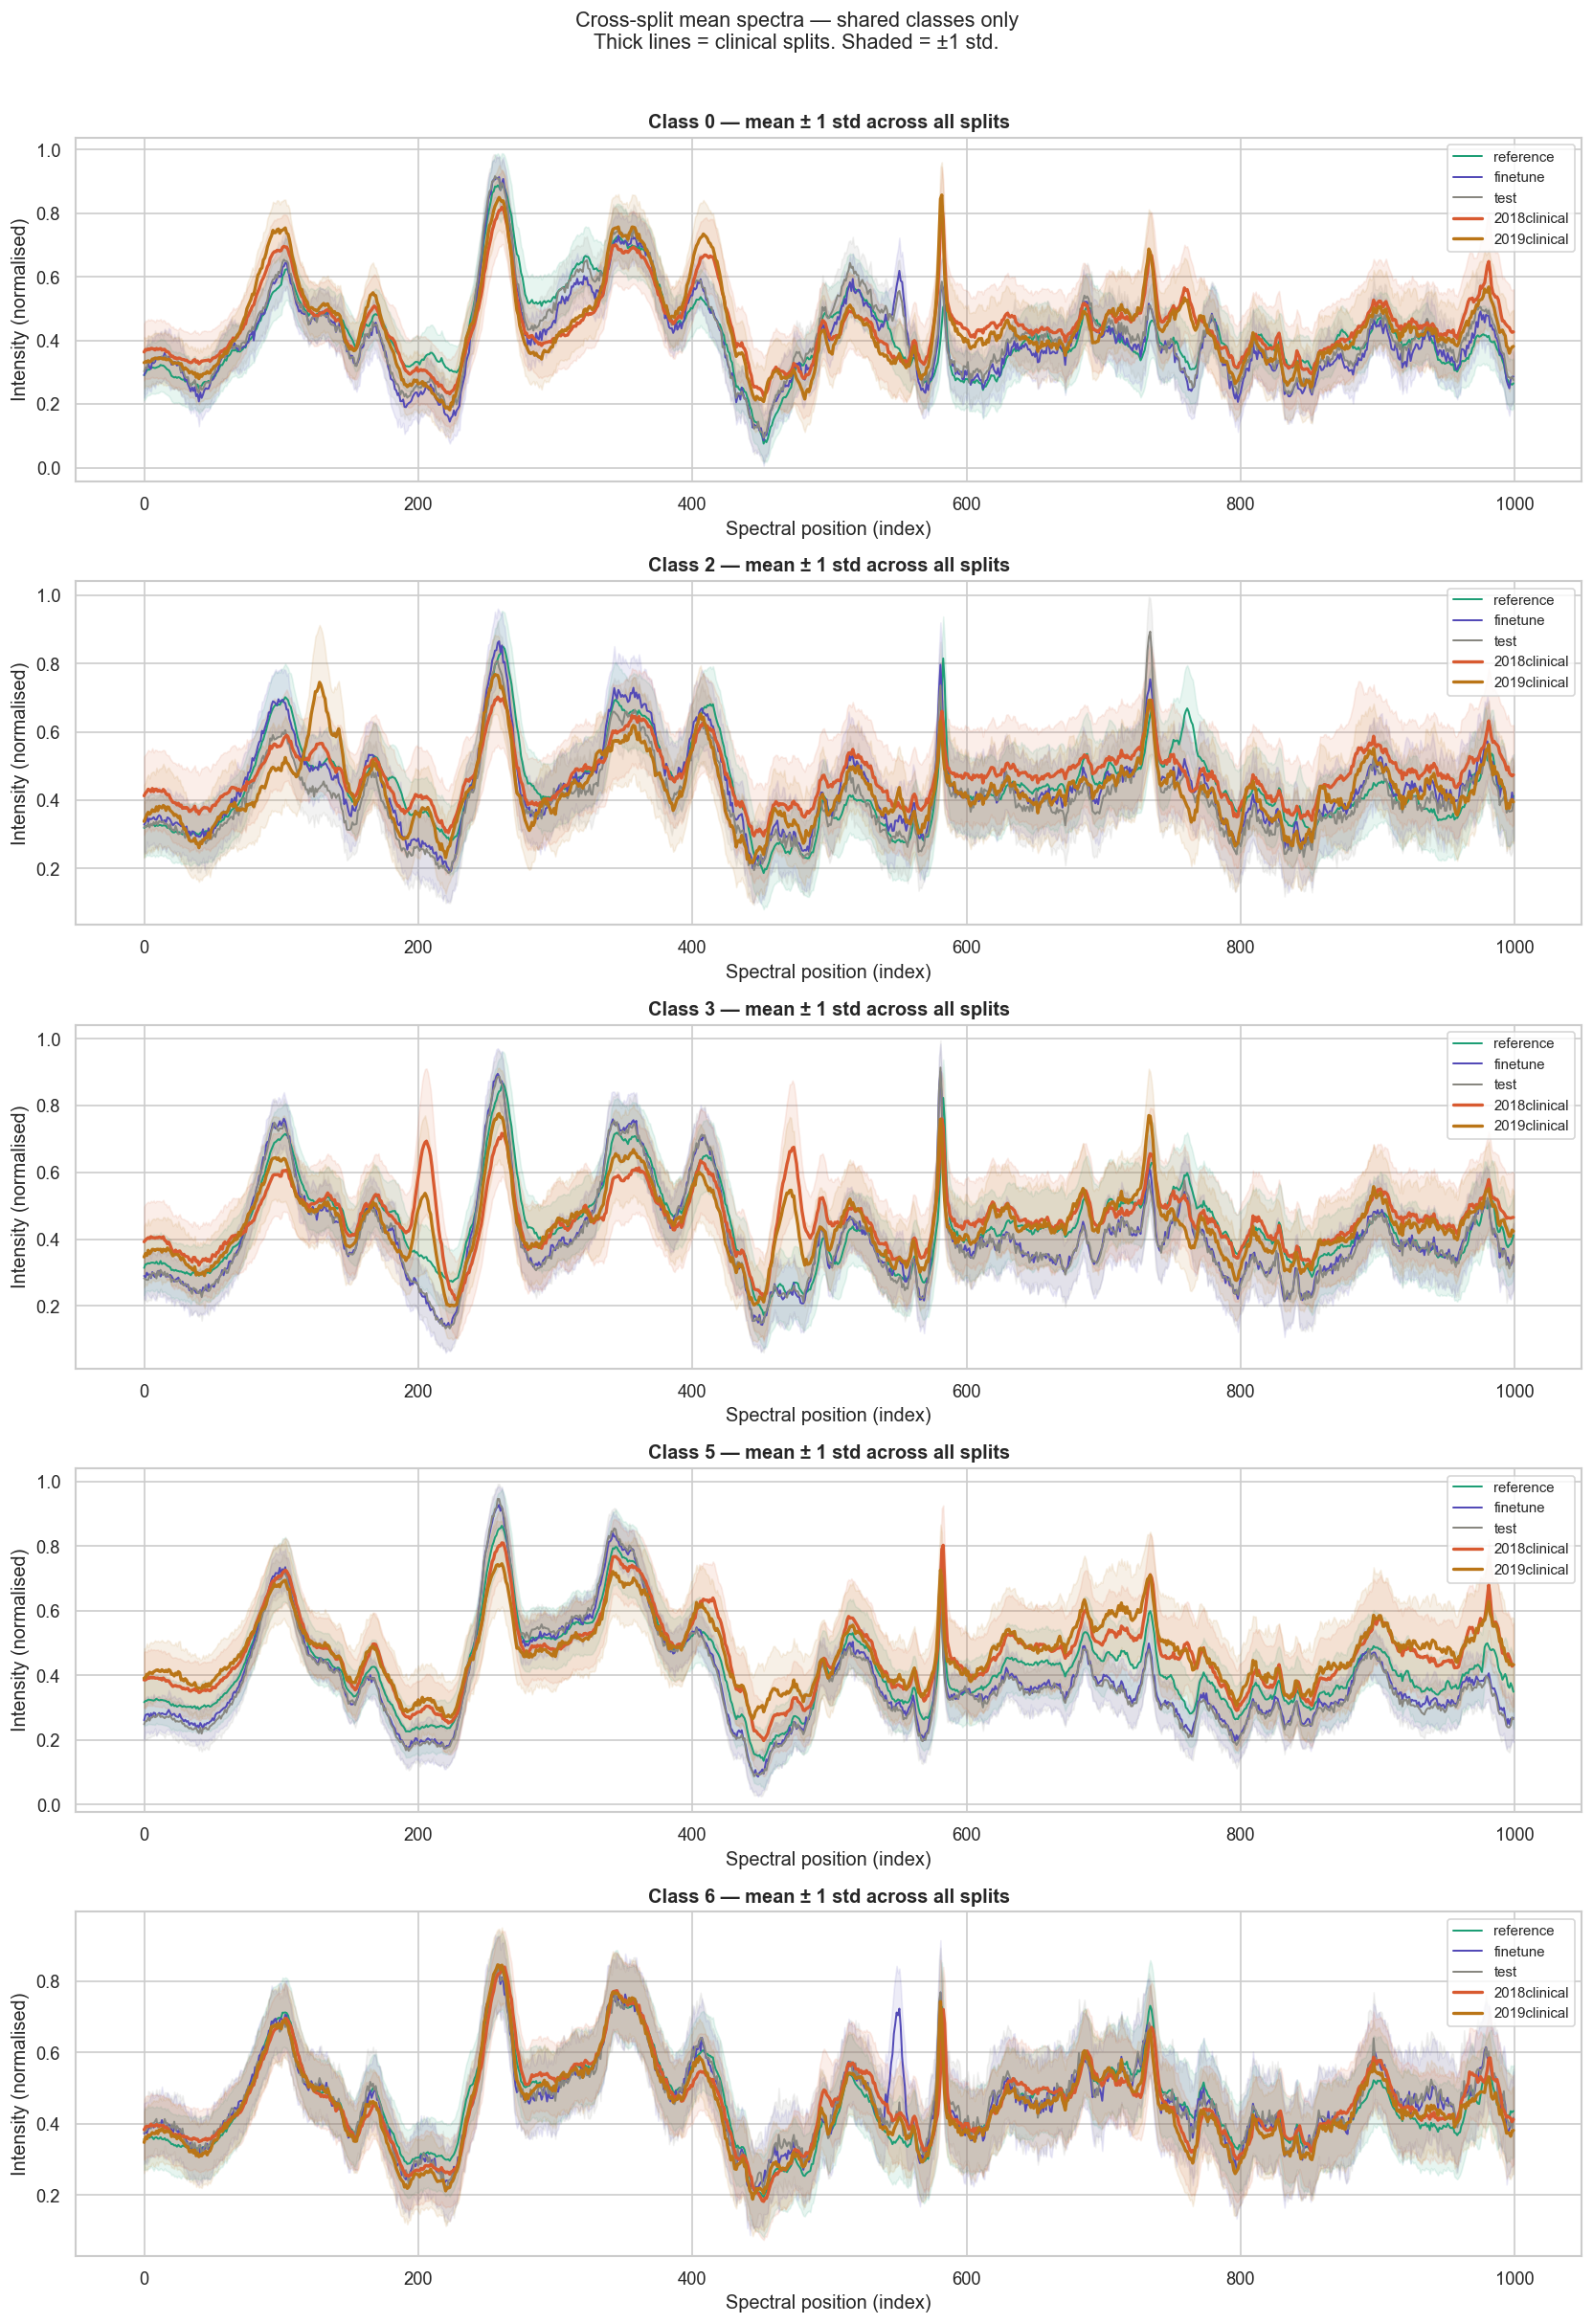

In [3]:
# ================================================================
# GAP 1 — Cross-split mean spectrum per shared class
# ================================================================
fig, axes = plt.subplots(len(SHARED_CLASSES), 1, figsize=(14, 4 * len(SHARED_CLASSES)))

for ax, cls in zip(axes, SHARED_CLASSES):
    for split in SPLITS:
        X, y = data[split]["X"], data[split]["y"]
        mask = y == cls
        if mask.sum() == 0:
            continue
        mean_sig = X[mask].mean(axis=0)
        std_sig  = X[mask].std(axis=0)
        color    = SPLIT_COLORS[split]
        lw       = 2.0 if split in CLINICAL_SPLITS else 1.2
        ax.plot(mean_sig, label=split, color=color, lw=lw)
        ax.fill_between(
            np.arange(len(mean_sig)),
            mean_sig - std_sig,
            mean_sig + std_sig,
            alpha=0.10, color=color
        )

    ax.set_title(f"Class {cls} — mean ± 1 std across all splits", fontweight="bold")
    ax.set_xlabel("Spectral position (index)")
    ax.set_ylabel("Intensity (normalised)")
    ax.legend(loc="upper right", fontsize=9)

plt.suptitle(
    "Cross-split mean spectra — shared classes only\n"
    "Thick lines = clinical splits. Shaded = ±1 std.",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig("../experiments/eda_gap1_cross_split_mean_spectra.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [4]:
# ================================================================
# GAP 1b — Absolute difference: reference vs each clinical split
# Quantifies EXACTLY how far the domain shifts per class
# ================================================================
print("Mean absolute difference (reference mean vs clinical mean) per class\n")
print(f"{'Class':>6}  {'vs 2018clinical':>17}  {'vs 2019clinical':>17}")
print("-" * 46)

ref_X, ref_y = data["reference"]["X"], data["reference"]["y"]

for cls in SHARED_CLASSES:
    ref_mean = ref_X[ref_y == cls].mean(axis=0)
    row = f"{cls:>6}"
    for csplit in CLINICAL_SPLITS:
        cX, cy = data[csplit]["X"], data[csplit]["y"]
        clin_mean = cX[cy == cls].mean(axis=0)
        mad = np.abs(ref_mean - clin_mean).mean()
        row += f"  {mad:>17.5f}"
    print(row)

Mean absolute difference (reference mean vs clinical mean) per class

 Class    vs 2018clinical    vs 2019clinical
----------------------------------------------
     0            0.07315            0.07344
     2            0.06015            0.05791
     3            0.05974            0.05079
     5            0.05344            0.06847
     6            0.02926            0.02740


---
## Gap 2 — Within-class variance per split

**What this tells us:** High within-class variance in clinical splits relative
to reference means the clinical data is noisier or more heterogeneous.
This informs how strong our augmentation needs to be — we want training-time
variance to match test-time variance so the model is not surprised.

In [5]:
# ================================================================
# GAP 2 — Within-class variance per split (mean point-wise std)
# ================================================================
variance_records = []

for split in SPLITS:
    X, y = data[split]["X"], data[split]["y"]
    for cls in np.unique(y):
        sigs = X[y == cls]
        mean_pointwise_std = sigs.std(axis=0).mean()   # avg std across all positions
        mean_signal_std    = sigs.mean(axis=1).std()   # std of per-sample means
        variance_records.append({
            "split": split,
            "class": int(cls),
            "mean_pointwise_std": mean_pointwise_std,
            "mean_signal_std":    mean_signal_std,
            "n_samples":          len(sigs),
        })

var_df = pd.DataFrame(variance_records)

C:\Users\Rohit\AppData\Local\Temp\ipykernel_23180\4076757824.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Rohit\AppData\Local\Temp\ipykernel_23180\4076757824.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


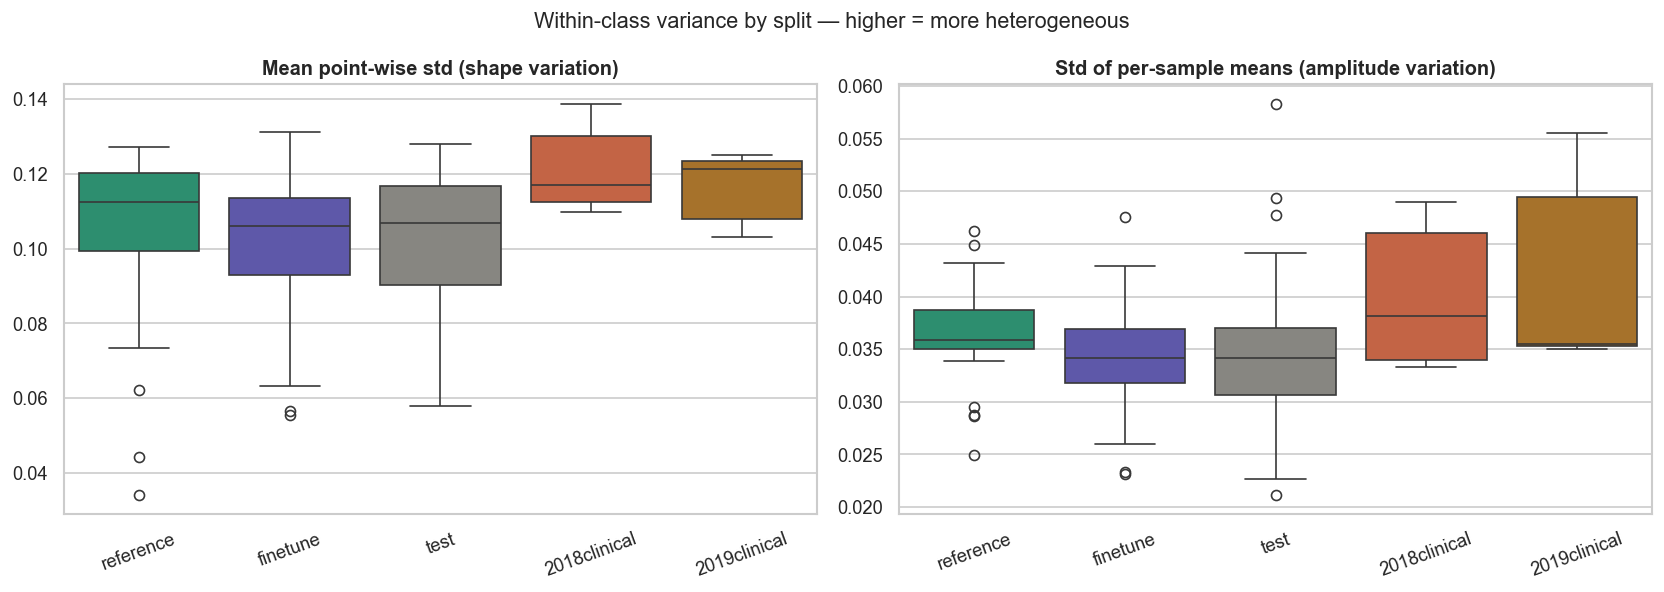

In [6]:
# Overall within-class variance distribution by split
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, label in zip(
    axes,
    ["mean_pointwise_std", "mean_signal_std"],
    ["Mean point-wise std (shape variation)", "Std of per-sample means (amplitude variation)"]
):
    sns.boxplot(
        data=var_df, x="split", y=metric, ax=ax,
        palette=SPLIT_COLORS, order=SPLITS
    )
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("Within-class variance by split — higher = more heterogeneous", fontsize=13)
plt.tight_layout()
plt.savefig("../experiments/eda_gap2_within_class_variance.png",
            dpi=150, bbox_inches="tight")
plt.show()

C:\Users\Rohit\AppData\Local\Temp\ipykernel_23180\1906649799.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cls_df["split"], rotation=30, ha="right", fontsize=8)
C:\Users\Rohit\AppData\Local\Temp\ipykernel_23180\1906649799.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cls_df["split"], rotation=30, ha="right", fontsize=8)
C:\Users\Rohit\AppData\Local\Temp\ipykernel_23180\1906649799.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cls_df["split"], rotation=30, ha="right", fontsize=8)
C:\Users\Rohit\AppData\Local\Temp\ipykernel_23180\1906649799.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fixed

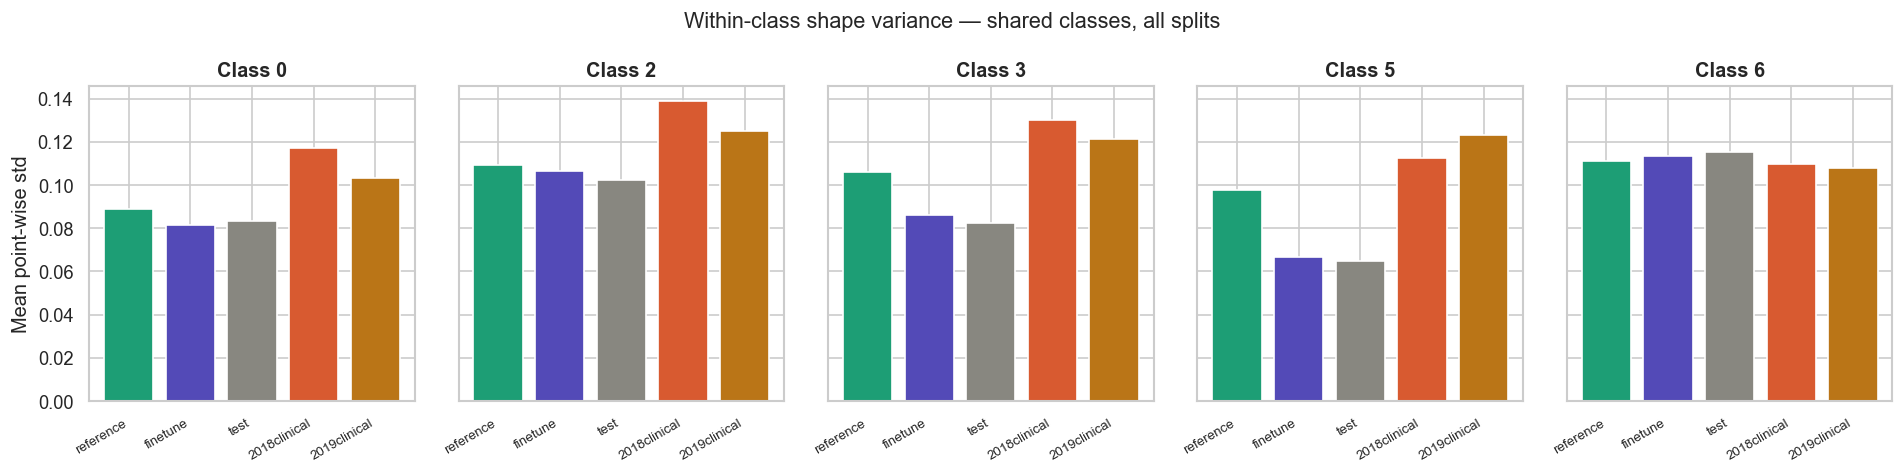


Mean point-wise std — summary table
split  2018clinical  2019clinical  finetune  reference     test
class                                                          
0           0.11701       0.10320   0.08143    0.08874  0.08318
2           0.13865       0.12503   0.10624    0.10941  0.10241
3           0.13010       0.12117   0.08632    0.10589  0.08242
5           0.11254       0.12333   0.06679    0.09788  0.06458
6           0.10975       0.10801   0.11320    0.11095  0.11544


In [7]:
# Focused: shared classes only, reference vs clinical
shared_var = var_df[var_df["class"].isin(SHARED_CLASSES)]

fig, axes = plt.subplots(1, len(SHARED_CLASSES), figsize=(16, 4), sharey=True)

for ax, cls in zip(axes, SHARED_CLASSES):
    cls_df = shared_var[shared_var["class"] == cls]
    colors  = [SPLIT_COLORS[s] for s in cls_df["split"]]
    ax.bar(cls_df["split"], cls_df["mean_pointwise_std"], color=colors)
    ax.set_title(f"Class {cls}", fontweight="bold")
    ax.set_xticklabels(cls_df["split"], rotation=30, ha="right", fontsize=8)

axes[0].set_ylabel("Mean point-wise std")
plt.suptitle("Within-class shape variance — shared classes, all splits", fontsize=13)
plt.tight_layout()
plt.savefig("../experiments/eda_gap2_shared_class_variance.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Summary table
print("\nMean point-wise std — summary table")
pivot = shared_var.pivot_table(
    index="class", columns="split", values="mean_pointwise_std"
).round(5)
print(pivot.to_string())

---
## Gap 3 — PCA restricted to shared classes only

**What this tells us:** In the full 30-class PCA, source and clinical splits
may appear well-mixed simply because they share the same 5-class subspace.
By isolating those 5 classes we can see whether the class clusters actually
align across domains, or whether each domain forms its own sub-cluster.

- **Well-aligned clusters**: domain shift is mild, direct transfer should work.
- **Split-separated clusters**: serious domain gap, fine-tuning will be necessary.
- **Class-separated clusters but split-mixed**: ideal — the model can learn
  class-discriminative features that transfer across domains.

In [8]:
# ================================================================
# GAP 3 — PCA on shared classes only
# ================================================================

# Collect shared-class samples from source splits + clinical splits
target_splits = ["reference", "2018clinical", "2019clinical"]
# Subsample reference to keep PCA tractable (use 500 per class = 2500 total)
SUBSAMPLE_PER_CLASS = 500

X_list, y_list, split_list = [], [], []

for split in target_splits:
    X, y = data[split]["X"], data[split]["y"]
    for cls in SHARED_CLASSES:
        mask = y == cls
        idx  = np.where(mask)[0]
        if len(idx) > SUBSAMPLE_PER_CLASS:
            rng = np.random.default_rng(42)
            idx = rng.choice(idx, SUBSAMPLE_PER_CLASS, replace=False)
        X_list.append(X[idx])
        y_list.append(y[idx])
        split_list.extend([split] * len(idx))

X_sub = np.vstack(X_list)
y_sub = np.concatenate(y_list).astype(int)
splits_sub = np.array(split_list)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sub)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA variance explained: PC1={pca.explained_variance_ratio_[0]:.3f}, "
      f"PC2={pca.explained_variance_ratio_[1]:.3f}")

PCA variance explained: PC1=0.135, PC2=0.064


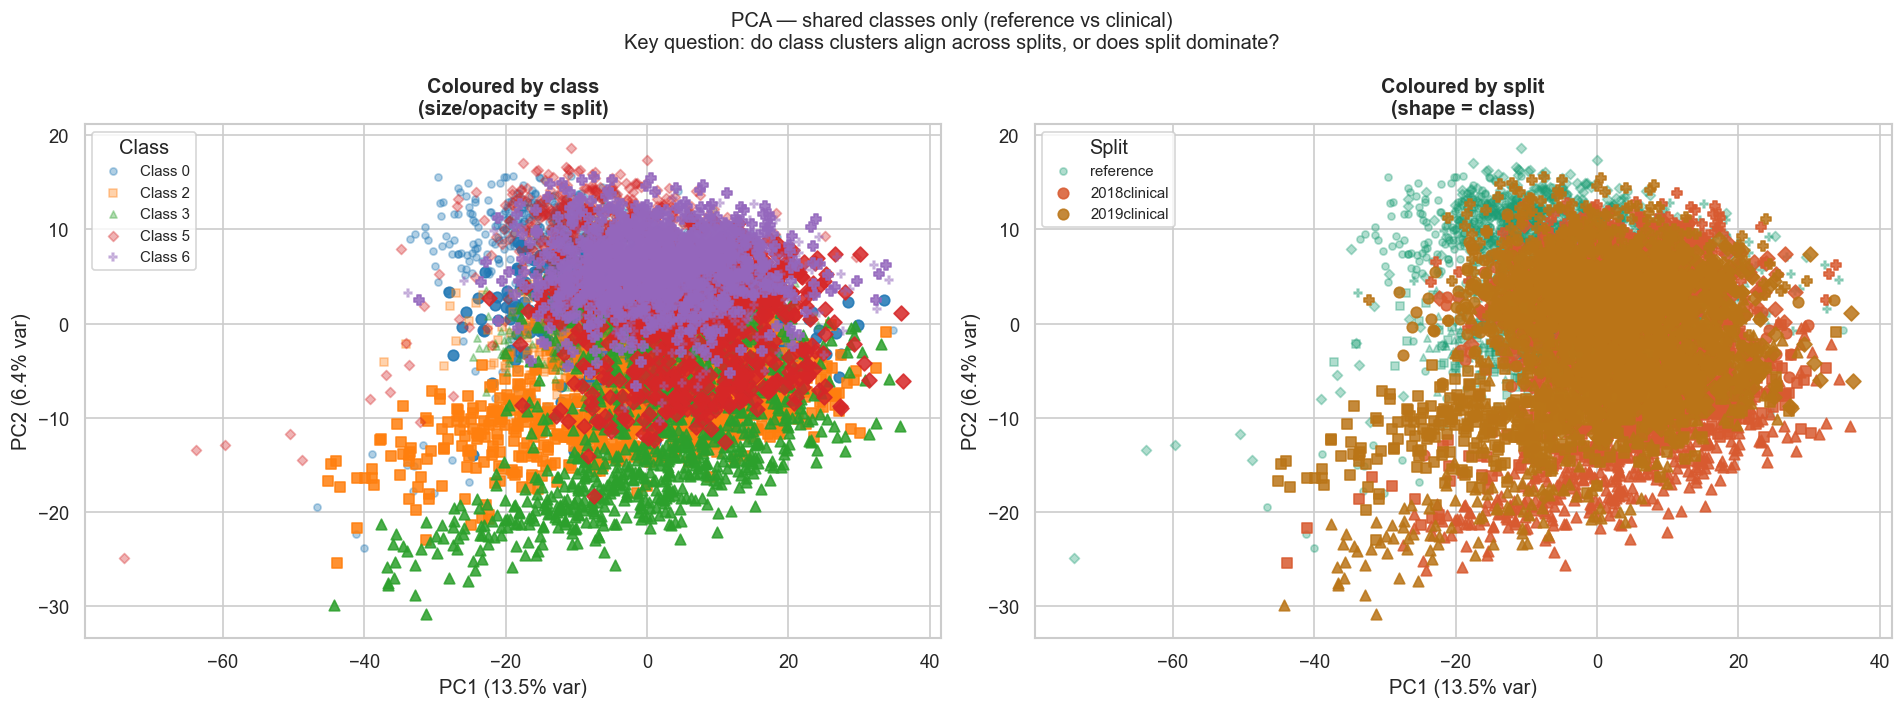

In [9]:
CLASS_MARKERS  = {0: "o", 2: "s", 3: "^", 5: "D", 6: "P"}
CLASS_PALETTE  = sns.color_palette("tab10", n_colors=len(SHARED_CLASSES))
CLASS_COLORS   = {cls: CLASS_PALETTE[i] for i, cls in enumerate(SHARED_CLASSES)}
SPLIT_ALPHAS   = {"reference": 0.35, "2018clinical": 0.85, "2019clinical": 0.85}
SPLIT_SIZES    = {"reference": 18,   "2018clinical": 40,   "2019clinical": 40}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---- Left: coloured by CLASS ----
ax = axes[0]
for cls in SHARED_CLASSES:
    for split in target_splits:
        mask = (y_sub == cls) & (splits_sub == split)
        ax.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            c=[CLASS_COLORS[cls]],
            marker=CLASS_MARKERS[cls],
            s=SPLIT_SIZES[split],
            alpha=SPLIT_ALPHAS[split],
            label=f"Class {cls}" if split == "reference" else "_"
        )

ax.set_title("Coloured by class\n(size/opacity = split)", fontweight="bold")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
ax.legend(title="Class", loc="best", fontsize=9)

# ---- Right: coloured by SPLIT ----
ax = axes[1]
for split in target_splits:
    for cls in SHARED_CLASSES:
        mask = (splits_sub == split) & (y_sub == cls)
        ax.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            c=[SPLIT_COLORS[split]],
            marker=CLASS_MARKERS[cls],
            s=SPLIT_SIZES[split],
            alpha=SPLIT_ALPHAS[split],
            label=split if cls == SHARED_CLASSES[0] else "_"
        )

ax.set_title("Coloured by split\n(shape = class)", fontweight="bold")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
ax.legend(title="Split", loc="best", fontsize=9)

plt.suptitle(
    "PCA — shared classes only (reference vs clinical)\n"
    "Key question: do class clusters align across splits, or does split dominate?",
    fontsize=12
)
plt.tight_layout()
plt.savefig("../experiments/eda_gap3_pca_shared_classes.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# ================================================================
# GAP 3b — Centroid distance table
# Quantifies how far each class centroid drifts across splits
# ================================================================
print("L2 distance between class centroids (PCA space): reference vs clinical\n")
print(f"{'Class':>6}  {'vs 2018clinical':>17}  {'vs 2019clinical':>17}")
print("-" * 46)

for cls in SHARED_CLASSES:
    ref_mask    = (y_sub == cls) & (splits_sub == "reference")
    ref_centroid = X_pca[ref_mask].mean(axis=0)
    row = f"{cls:>6}"
    for csplit in CLINICAL_SPLITS:
        c_mask     = (y_sub == cls) & (splits_sub == csplit)
        if c_mask.sum() == 0:
            row += f"  {'N/A':>17}"
            continue
        c_centroid = X_pca[c_mask].mean(axis=0)
        dist       = np.linalg.norm(ref_centroid - c_centroid)
        row += f"  {dist:>17.4f}"
    print(row)

L2 distance between class centroids (PCA space): reference vs clinical

 Class    vs 2018clinical    vs 2019clinical
----------------------------------------------
     0            15.8905            10.0775
     2            11.5603             7.8820
     3            14.8147             6.9853
     5            12.9850            18.0377
     6             1.7369             3.1312


---
## Interpretation Guide

Filled from the actual outputs above:

| Observation | Implication |
|---|---|
| Mean spectra keep broadly similar peak locations across splits, but clinical curves often show baseline/intensity offsets; this is strongest for classes 0, 3, and 5 | Prioritise baseline correction and robust intensity normalisation; peak-shift augmentation is lower priority than handling amplitude/baseline mismatch |
| Mean absolute difference between reference and clinical means is moderate for classes 0, 2, 3, and 5 (~0.05-0.07) and smallest for class 6 (~0.03) | Domain shift is class-dependent; class 6 should transfer most easily, while 0/2/3/5 need more adaptation support |
| Within-class shape variance is higher in clinical for classes 0, 2, 3, and 5, while class 6 stays close to reference | Clinical data is noisier/more heterogeneous for most shared classes, so stronger noise/shape augmentation is justified, especially for 0/2/3/5 |
| PCA shows class structure, but splits are not fully mixed; reference is visibly shifted relative to the clinical clouds | Direct transfer from reference alone is unlikely to be enough; clinical fine-tuning is important even though the shared classes still occupy a related feature space |
| Centroid distances are large for most classes (0, 2, 3, 5: about 7.0-18.0) and small only for class 6 (about 1.7-3.1) | The domain gap is significant for most shared classes, so fine-tuning/domain adaptation should be the default strategy; class 6 is the main exception |
| 2018clinical is usually farther from reference than 2019clinical for classes 0, 2, and 3, but class 5 drifts most in 2019clinical | Shift is not uniform across clinical cohorts, so evaluation and adaptation decisions should be reported per class and per clinical split, not only as one aggregate metric |


In [6]:
import os
os.getcwd()

's:\\raman-spectral-classifier\\notebooks'

In [7]:
import os

os.listdir("../experiments")

['cnn_20260420_234611',
 'cnn_20260420_235319',
 'cnn_debug',
 'cnn_finetuned',
 'cnn_v1',
 'eda_gap1_cross_split_mean_spectra.png',
 'eda_gap2_shared_class_variance.png',
 'eda_gap2_within_class_variance.png',
 'eda_gap3_pca_shared_classes.png',
 '_tmp_tests']

In [8]:
os.listdir("../experiments/cnn_v1")

['checkpoints', 'config.json', 'config.yaml', 'metrics.json', 'summary.json']

In [9]:
os.listdir("../experiments/cnn_v1/checkpoints")

['best.pt',
 'epoch_001.pt',
 'epoch_002.pt',
 'epoch_003.pt',
 'epoch_004.pt',
 'epoch_005.pt',
 'epoch_006.pt']

In [10]:
CKPT_PATH = "../experiments/cnn_v1/checkpoints/best.pth"

In [12]:
import sys
import os

sys.path.append(os.path.abspath(".."))

Model loaded successfully
['processed', 'raw', 'splits']
Extracting features...
Output keys: dict_keys(['main_logits', 'features', 'domain_logits'])
Output keys: dict_keys(['main_logits', 'features', 'domain_logits'])
Explained variance: [0.72028846 0.07397328]


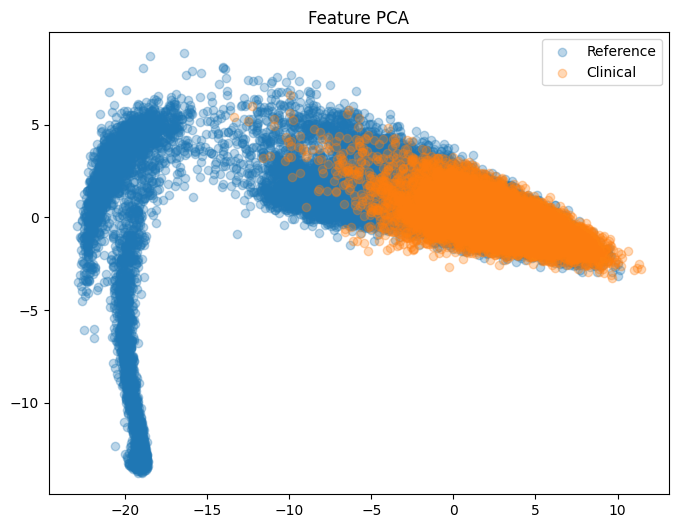

In [41]:
# ============================================
# FEATURE PCA (FINAL CORRECT VERSION)
# ============================================

import sys, os
sys.path.append(os.path.abspath(".."))

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# LOAD CHECKPOINT
# -----------------------------
CKPT_PATH = "../experiments/cnn_v1/checkpoints/best.pt"
ckpt = torch.load(CKPT_PATH, map_location=device)

# -----------------------------
# LOAD CONFIG
# -----------------------------
from src.utils.config import load_config

CONFIG_PATH = "../configs/model/cnn.yaml"
cfg = load_config(CONFIG_PATH)

model_cfg = cfg["model"].copy()
model_cfg.pop("name", None)   # remove 'name' key

# -----------------------------
# BUILD MODEL
# -----------------------------
from src.models.cnn import CNN1D

model = CNN1D(**model_cfg)

# -----------------------------
# LOAD WEIGHTS
# -----------------------------
model.load_state_dict(ckpt["model_state"], strict=False)

model = model.to(device)
model.eval()

print("Model loaded successfully")

# -----------------------------
# LOAD DATA
# -----------------------------
import os
print(os.listdir("../data"))

import numpy as np

X_ref = np.load("../data/raw/X_reference.npy")
X_clin_2018 = np.load("../data/raw/X_2018clinical.npy")
X_clin_2019 = np.load("../data/raw/X_2019clinical.npy")

X_clin = np.concatenate([X_clin_2018, X_clin_2019], axis=0)

# -----------------------------
# TO TENSOR
# -----------------------------
X_ref = torch.tensor(X_ref, dtype=torch.float32).unsqueeze(1)
X_clin = torch.tensor(X_clin, dtype=torch.float32).unsqueeze(1)

# -----------------------------
# FEATURE EXTRACTION
# -----------------------------
def get_features(X):
    feats = []
    with torch.no_grad():
        for i in range(0, len(X), 256):
            batch = X[i:i+256].to(device)
            out = model(batch)

            if i == 0:
                print("Output keys:", out.keys())

            feats.append(out["features"].cpu().numpy())
    return np.concatenate(feats)

print("Extracting features...")
f_ref = get_features(X_ref)
f_clin = get_features(X_clin)

# -----------------------------
# PCA
# -----------------------------
X_all = np.concatenate([f_ref, f_clin])
y = np.array([0]*len(f_ref) + [1]*len(f_clin))

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_all)

print("Explained variance:", pca.explained_variance_ratio_)

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(8,6))
plt.scatter(X_pca[y==0,0], X_pca[y==0,1], alpha=0.3, label="Reference")
plt.scatter(X_pca[y==1,0], X_pca[y==1,1], alpha=0.3, label="Clinical")
plt.legend()
plt.title("Feature PCA")
plt.show()

In [35]:
import os
print(os.listdir(".."))

['.git', '.gitignore', '.pytest_cache', 'app', 'configs', 'conftest.py', 'data', 'docs', 'experiments', 'notebooks', 'pyproject.toml', 'README.md', 'requirements.txt', 'scripts', 'src', 'tests', 'venv', 'whatever', '__pycache__']
